In [1]:
import re
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.notebook import tqdm
from scipy.ndimage import gaussian_filter

import matplotlib.patches as mpatches
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

from instruct_rl.utils.result import (
    get_initial_state,
    calculate_progress,
    calculate_direction,
)

In [2]:
# -----------------------------
# Utils for data processing
# -----------------------------
def process_result(raw_df: pd.DataFrame) -> pd.DataFrame:
    """calculate and add progress to raw eval dataframe."""
    df = raw_df.copy()

    initial_df = get_initial_state()
    df = pd.merge(df, initial_df, on="seed", how="left")

    # progress metrics
    df["progress_region"]  = df.apply(lambda row: calculate_progress(row, "condition_0", "feat_region"), axis=1)
    df["progress_plength"] = df.apply(lambda row: calculate_progress(row, "condition_1", "feat_plength"), axis=1)
    df["progress_nblock"]  = df.apply(lambda row: calculate_progress(row, "condition_2", "feat_nblock"), axis=1)
    df["progress_nbat"]    = df.apply(lambda row: calculate_progress(row, "condition_3", "feat_nbat"), axis=1)
    df["progress_batdir"]  = df.apply(lambda row: calculate_direction(row, "condition_4"), axis=1)

    df = df.rename(columns={
        "condition_0": "cond_region",
        "condition_1": "cond_plength",
        "condition_2": "cond_nblock",
        "condition_3": "cond_nbat",
        "condition_4": "cond_batdir",
    })
    return df


def extract_data(method: str) -> pd.DataFrame:
    """reading loss.csv from saves and convert to DataFrame"""

    saves_path = Path(f"../saves/{method}")
    pattern = r"embed-bert_inst-scn-\d+_se-(\d+)"  # sampling se_number by folder name

    loss_csv_files = list(saves_path.glob("embed-bert_inst-scn-*/eval_embed-bert_inst-whole/loss.csv"))
    print(f"Found {len(loss_csv_files)} loss.csv files")

    dfs_progress = []
    for loss_file in tqdm(loss_csv_files, desc="Loading loss.csv files from saves"):
        folder_name = loss_file.parent.parent.name
        m = re.search(pattern, folder_name)
        if not m:
            continue

        se_number = int(m.group(1))
        df_loss = pd.read_csv(loss_file)
        df_loss["se_number"] = se_number
        df_loss["folder_name"] = folder_name
        dfs_progress.append(df_loss)

    df_combined = pd.concat(dfs_progress, ignore_index=True)

    # remaining required row
    df_combined = df_combined[
        pd.to_numeric(df_combined["se_number"], errors="coerce").astype("Int64")
        == pd.to_numeric(df_combined["reward_enum"], errors="coerce").astype("Int64")
    ].copy()

    print("df_combined shape after filter:", df_combined.shape)

    # calculate progress
    df_combined = process_result(df_combined)

    return df_combined

In [3]:
ipcgrl_df = extract_data("ipcgrl")
mipcgrl_df = extract_data("mipcgrl")

Found 15 loss.csv files


Loading loss.csv files from saves:   0%|          | 0/15 [00:00<?, ?it/s]

df_combined shape after filter: (38400, 27)
Found 18 loss.csv files


Loading loss.csv files from saves:   0%|          | 0/18 [00:00<?, ?it/s]

df_combined shape after filter: (38400, 27)


In [4]:
# -----------------------------
# Utils for draw plot
# -----------------------------
def _hdr_levels_from_density(density_2d: np.ndarray, mass_levels=(0.5, 0.8, 0.95)):
    """
    Compute the density thresholds (levels) for a density_2d (>= 0) such that
    the highest-density regions contain a specified fraction of the total probability mass (mass_levels).

    Returns: levels ordered from high to low, which can be directly used as contour levels.
    """
    D = np.asarray(density_2d, dtype=float)
    D = np.clip(D, 0, None)

    total = D.sum()
    if total <= 0:
        return []

    flat = D.ravel()
    order = np.argsort(flat)[::-1]
    sorted_vals = flat[order]
    cumsum = np.cumsum(sorted_vals)

    levels = []
    for m in mass_levels:
        target = m * total
        idx = np.searchsorted(cumsum, target, side="left")
        idx = min(idx, len(sorted_vals) - 1)
        levels.append(sorted_vals[idx])

    levels = sorted(set(levels))
    return levels


def add_arrow(fig, x, y, angle_deg, length=0.05,
              width=0.008, head_width=0.018, head_length=0.015,
              color="black", alpha=1.0):
    """draw arrow shape on plot"""

    fig_width, fig_height = fig.get_size_inches()
    rad = np.deg2rad(angle_deg)

    #draw on inch
    x_inch = x * fig_width
    y_inch = y * fig_height
    length_inch = length * fig_height

    #rotate
    end_x_inch = x_inch + np.cos(rad) * length_inch
    end_y_inch = y_inch + np.sin(rad) * length_inch

    #calculate coordinate
    end_x = end_x_inch / fig_width
    end_y = end_y_inch / fig_height

    # convert inch to pixel: 1 inch = 72 points
    tail_width_pt = width * fig_height * 72
    head_width_pt = head_width * fig_height * 72
    head_length_pt = head_length * fig_height * 72

    #draw
    arrow = mpatches.FancyArrowPatch(
        posA=(x, y),
        posB=(end_x, end_y),
        arrowstyle=mpatches.ArrowStyle.Simple(
            head_width=head_width_pt,
            head_length=head_length_pt,
            tail_width=tail_width_pt,
        ),
        color=color,
        alpha=alpha,
        transform=fig.transFigure,
        clip_on=False,
        linewidth=0,
    )
    fig.add_artist(arrow)
    return arrow

In [5]:
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
font_props = {"fontfamily": "Times New Roman"}

reward_enum_dict = {
    14: ["region", "nbat"],
    24: ["plength", "nbat"],
    25: ["plength", "batdir"],
    35: ["nblock", "batdir"],
    45: ["nbat", "batdir"],
}

task_colors = {
    14: "#F4C4A7",
    24: "#F4A7A7",
    25: "#A7F4B0",
    35: "#A7D4F4",
    45: "#D4A7F4",
}

task_zorder = {
    14: 3,
    24: 4,
    25: 2,
    35: 1,
    45: 0,
}

In [6]:
def visualization_all_multitask_heatmap(
    ipcgrl_df: pd.DataFrame,
    mipcgrl_df: pd.DataFrame,
    multitask_list: list = [14, 24, 25, 35, 45],
    switch_xy_list: list = [],
    bins: int = 80,
    log_scale: bool = True,
    cmap_name: str = "Blues",
    density_sigma: float = 0.0,
    density_mass_levels: tuple = (0.0, 1.0)
):

    task_data = {}
    for reward_type in multitask_list:
        if reward_type in switch_xy_list:
            y_col_type, x_col_type = reward_enum_dict[reward_type]
            y_col = f"progress_{x_col_type}"
            x_col = f"progress_{y_col_type}"
        else:
            x_col_type, y_col_type = reward_enum_dict[reward_type]
            x_col = f"progress_{x_col_type}"
            y_col = f"progress_{y_col_type}"

        ipc = ipcgrl_df[ipcgrl_df["se_number"] == reward_type].copy()
        ipc[x_col] = pd.to_numeric(ipc[x_col], errors="coerce")
        ipc[y_col] = pd.to_numeric(ipc[y_col], errors="coerce")
        ipc.dropna(subset=[x_col, y_col], inplace=True)
        ipc = ipc[(ipc[x_col] != 0) & (ipc[y_col] != 0)].copy()

        mip = mipcgrl_df[mipcgrl_df["se_number"] == reward_type].copy()
        mip[x_col] = pd.to_numeric(mip[x_col], errors="coerce")
        mip[y_col] = pd.to_numeric(mip[y_col], errors="coerce")
        mip.dropna(subset=[x_col, y_col], inplace=True)
        mip = mip[(mip[x_col] != 0) & (mip[y_col] != 0)].copy()

        task_data[reward_type] = {
            "ipc_x": ipc[x_col].values,
            "ipc_y": ipc[y_col].values,
            "mip_x": mip[x_col].values,
            "mip_y": mip[y_col].values,
        }

    all_ipc_x = np.concatenate([task_data[t]["ipc_x"] for t in multitask_list])
    all_ipc_y = np.concatenate([task_data[t]["ipc_y"] for t in multitask_list])
    all_mip_x = np.concatenate([task_data[t]["mip_x"] for t in multitask_list])
    all_mip_y = np.concatenate([task_data[t]["mip_y"] for t in multitask_list])

    xmin = min(all_ipc_x.min(), all_mip_x.min())
    xmax = max(all_ipc_x.max(), all_mip_x.max())
    ymin = min(all_ipc_y.min(), all_mip_y.min())
    ymax = max(all_ipc_y.max(), all_mip_y.max())

    dmin = 0.0
    dmax = 0.4

    H0_all, xedges, yedges = np.histogram2d(
        all_ipc_x, all_ipc_y,
        bins=bins, range=[[xmin, xmax], [ymin, ymax]]
    )
    H1_all, _, _ = np.histogram2d(
        all_mip_x, all_mip_y,
        bins=[xedges, yedges]
    )

    if log_scale:
        nonzero = np.concatenate([H0_all[H0_all > 0].ravel(), H1_all[H1_all > 0].ravel()])
        if nonzero.size == 0:
            norm = None
        else:
            vmin = max(1.0, np.percentile(nonzero, 5.0))
            vmax = np.percentile(nonzero, 99.5)
            if vmax <= vmin:
                vmax = vmin + 1.0
            norm = LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = None

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_under((0, 0, 0, 0))

    bin_step = 5
    bin_edges = np.arange(0, 101, bin_step)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bar_width = bin_step

    def _norm_hist(h):
        s = h.sum()
        return h / s if s > 0 else h.astype(float)

    fig = plt.figure(figsize=(8, 5))

    left_start   = 0.00
    right_end    = 1.00
    bottom_start = 0.18
    top_end      = 1.0
    cbar_h       = 0.04
    cbar_gap     = 0.01
    mid_gap      = -0.03

    dens_right_ratio = 0.2
    dens_top_ratio   = 0.2
    total_w = right_end - left_start - mid_gap
    hm_w = total_w / 2 * (1 - dens_right_ratio)
    dr_w = total_w / 2 * dens_right_ratio
    total_h = top_end - bottom_start
    hm_h = total_h * (1 - dens_top_ratio)
    dt_h = total_h * dens_top_ratio
    x_ipc_hm = left_start
    x_ipc_dr = left_start + hm_w
    x_mip_hm = left_start + hm_w + dr_w + mid_gap
    x_mip_dr = left_start + hm_w + dr_w + mid_gap + hm_w
    y_hm     = bottom_start
    y_dt     = bottom_start + hm_h
    cbar_bottom = cbar_gap * 0.3
    cbar_left   = left_start
    cbar_width  = (hm_w ) * 2 + dr_w + mid_gap

    #figure structure
    ax0_top   = fig.add_axes([x_ipc_hm, y_dt, hm_w, dt_h])
    ax0_right = fig.add_axes([x_ipc_dr, y_hm, dr_w, hm_h])
    ax0       = fig.add_axes([x_ipc_hm, y_hm, hm_w, hm_h])
    ax1_top   = fig.add_axes([x_mip_hm, y_dt, hm_w, dt_h])
    ax1_right = fig.add_axes([x_mip_dr, y_hm, dr_w, hm_h])
    ax1       = fig.add_axes([x_mip_hm, y_hm, hm_w, hm_h])

    cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_h])

    # draw heatmap
    h0, _, _, mesh0 = ax0.hist2d(
        all_ipc_x, all_ipc_y,
        bins=[xedges, yedges],
        range=[[xmin, xmax], [ymin, ymax]],
        norm=norm, cmap=cmap
    )
    mesh0.set_rasterized(True)
    ax0.set_box_aspect(1)
    h1 , _, _, mesh1 = ax1.hist2d(
        all_mip_x, all_mip_y,
        bins=[xedges, yedges],
        range=[[xmin, xmax], [ymin, ymax]],
        norm=norm, cmap=cmap
    )
    mesh1.set_rasterized(True)
    ax1.set_box_aspect(1)

    # calculate HDR contour
    H0_blur = gaussian_filter(H0_all.astype(float), sigma=density_sigma)
    H1_blur = gaussian_filter(H1_all.astype(float), sigma=density_sigma)
    xc = (xedges[:-1] + xedges[1:]) / 2.0
    yc = (yedges[:-1] + yedges[1:]) / 2.0
    X, Y = np.meshgrid(xc, yc)
    lev0 = _hdr_levels_from_density(H0_blur, mass_levels=density_mass_levels)
    lev1 = _hdr_levels_from_density(H1_blur, mass_levels=density_mass_levels)

    #draw HDR contour
    if len(lev0) > 0:
        ax0.contour(X, Y, H0_blur.T, levels=lev0, linewidths=2.0, colors=[(1, 0, 0)])
        ax1.contour(X, Y, H0_blur.T, levels=lev0, linewidths=2.0, linestyles="--", colors=[(1, 0, 0)], alpha=1)
    if len(lev1) > 0:
        ax1.contour(X, Y, H1_blur.T, levels=lev1, linewidths=2.0, colors=[(1, 0, 0)])

    ax0.set_xlim(xmin, xmax)
    ax0.set_ylim(ymin, ymax)
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)

    #add left-bottom text
    ax0.text(0.02, 0.02, r"\textbf{(a) IPCGRL}",
             transform=ax0.transAxes, fontsize=16, fontweight="bold",
             fontfamily="Times New Roman", ha="left", va="bottom", color="black")
    ax1.text(0.02, 0.02, r"\textbf{(b) MIPCGRL}",
             transform=ax1.transAxes, fontsize=16, fontweight="bold",
             fontfamily="Times New Roman", ha="left", va="bottom", color="black")

    #labels
    ax0.set_xlabel(r"Objective I  Progress", fontsize=14, **font_props)
    ax0.set_ylabel(r"Objective \text{II}  Progress", fontsize=14, **font_props)
    ax0.tick_params(axis="both", labelsize=12)
    for lbl in ax0.get_xticklabels() + ax0.get_yticklabels():
        lbl.set_fontfamily("Times New Roman")
    ax0.grid(True, alpha=0.2)
    ax1.set_xlabel(r"Objective \text{I}  Progress", fontsize=14, **font_props)
    ax1.tick_params(axis="x", labelsize=12)
    ax1.tick_params(axis="y", labelleft=False)
    for lbl in ax1.get_xticklabels():
        lbl.set_fontfamily("Times New Roman")
    ax1.grid(True, alpha=0.2)

    #subgraph: top-side and right-side graph for each task
    for reward_type in [14,24,25,35,45]:
        d = task_data[reward_type]
        color = task_colors.get(reward_type, "#CCCCCC")
        zo = task_zorder.get(reward_type, 1)
        label = f"Task {reward_type}"

        ipc_xd = _norm_hist(np.histogram(d["ipc_x"], bins=bin_edges)[0])
        ipc_yd = _norm_hist(np.histogram(d["ipc_y"], bins=bin_edges)[0])
        mip_xd = _norm_hist(np.histogram(d["mip_x"], bins=bin_edges)[0])
        mip_yd = _norm_hist(np.histogram(d["mip_y"], bins=bin_edges)[0])

        ax0_top.bar(bin_centers, ipc_xd, width=bar_width, color=color,
                    edgecolor="none", alpha=0.6, zorder=zo, label=label)
        ax0_right.barh(bin_centers, ipc_yd, height=bar_width, color=color,
                       edgecolor="none", alpha=0.6, zorder=zo)
        ax1_top.bar(bin_centers, mip_xd, width=bar_width, color=color,
                    edgecolor="none", alpha=0.6, zorder=zo, label=label)
        ax1_right.barh(bin_centers, mip_yd, height=bar_width, color=color,
                       edgecolor="none", alpha=0.6, zorder=zo)

    # spines
    for ax_dens in [ax0_top, ax0_right, ax1_top, ax1_right]:
        ax_dens.set_xticks([])
        ax_dens.set_yticks([])
        for spine in ax_dens.spines.values():
            spine.set_visible(False)
            spine.set_linewidth(0.8)
            spine.set_edgecolor("gray")

    #set scale
    ax0_top.set_xlim(xmin, xmax)
    ax0_right.set_ylim(ymin, ymax)
    ax1_top.set_xlim(xmin, xmax)
    ax1_right.set_ylim(ymin, ymax)

    #set scale: for subgraph
    ax0_top.set_ylim(dmin, dmax)
    ax0_right.set_xlim(dmin, dmax)
    ax1_top.set_ylim(dmin, dmax)
    ax1_right.set_xlim(dmin, dmax+0.32)

    # colorbar
    cb = fig.colorbar(mesh1, cax=cax, orientation="horizontal")
    cb.set_label("Density (log-scale)", fontsize=14, **font_props)
    cb.ax.tick_params(labelsize=12)
    for lbl in cb.ax.get_xticklabels():
        lbl.set_fontfamily("Times New Roman")

    mpl.rcParams["mathtext.fontset"] = "custom"
    mpl.rcParams["mathtext.rm"] = "Times New Roman"
    mpl.rcParams["mathtext.it"] = "Times New Roman:italic"
    mpl.rcParams["mathtext.bf"] = "Times New Roman:bold"

    # legend elements
    patch_elements = [
        Patch(facecolor=task_colors[35], edgecolor="none", alpha=1, label=r"$\tau _{WC \oplus BD}$"),
        Patch(facecolor=task_colors[45], edgecolor="none", alpha=1, label=r"$\tau _{BC \oplus BD}$"),
        Patch(facecolor=task_colors[14], edgecolor="none", alpha=1, label=r"$\tau _{RG \oplus BC}$"),
        Patch(facecolor=task_colors[24], edgecolor="none", alpha=1, label=r"$\tau _{PL \oplus BC}$"),
        Patch(facecolor=task_colors[25], edgecolor="none", alpha=1, label=r"$\tau _{PL \oplus BD}$"),
    ]
    line_elements = [
        Line2D([0], [0], color=(1, 0, 0), linewidth=2.0, linestyle="--", label="IPCGRL"),
        Line2D([0], [0], color=(1, 0, 0), linewidth=2.0, linestyle="-",  label="MIPCGRL"),
    ]

    legend_font = {"family": "Times New Roman", "size": 14}
    legend_common = dict(
        bbox_transform=fig.transFigure,
        framealpha=0.85,
        edgecolor="gray",
        prop=legend_font,
        handlelength=1.5,
        columnspacing=1.0,
        handletextpad=0.5,
    )
    # Patch legend (left side)
    fig.legend(
        handles=patch_elements,
        loc="lower center",
        bbox_to_anchor=(cbar_left + cbar_width / 2 - 0.16, -0.25),
        title=r"\textbf{Objective}",
        title_fontproperties={"family": "Times New Roman", "size": 13, "weight": "bold"},
        ncol=len(patch_elements),
        **legend_common,
    )
    # Line2D legend (right side)
    fig.legend(
        handles=line_elements,
        loc="lower center",
        bbox_to_anchor=(cbar_left + cbar_width / 2 + 0.4, -0.25),
        title=r"\textbf{95\% HDR Contour}",
        title_fontproperties={"family": "Times New Roman", "size": 13, "weight": "bold"},
        ncol=len(line_elements),
        **legend_common,
    )

    #add arrow
    add_arrow(fig, x=0.64, y=0.47, angle_deg=80,   length=0.06, width=0.02, head_length=0.03, head_width=0.04, color=(1, 0.5, 0), alpha=0.8)
    add_arrow(fig, x=0.72, y=0.41, angle_deg=50,   length=0.06, width=0.02, head_length=0.03, head_width=0.04, color=(1, 0.5, 0), alpha=0.8)
    add_arrow(fig, x=0.78, y=0.3, angle_deg=25,   length=0.06, width=0.02, head_length=0.03, head_width=0.04, color=(1, 0.5, 0), alpha=0.8)

    ax1.text(
        1.03, 1.03, "Density \nper Obj.",
        transform=ax0.transAxes, fontsize=12, fontfamily="Times New Roman", ha="left", va="bottom", color="Black",
    )
    ax1.text(
        1.03, 1.03, "Density \nper Obj.",
        transform=ax1.transAxes, fontsize=12, fontfamily="Times New Roman", ha="left", va="bottom", color="Black",
    )

    ax0.text(
        0.34, 0.4, r"\textbf{0.76}",
        transform=ax0.transAxes, fontsize=14, fontfamily="Times New Roman", ha="center", va="bottom", color="Red", rotation = 355,
    )
    ax1.text(
        0.675, 0.47, r"\textbf{0.53}",
        transform=ax1.transAxes, fontsize=14, fontfamily="Times New Roman", ha="center", va="bottom", color="Red", rotation = 332,
    )

    fig.savefig("../saves/density.pdf", bbox_inches="tight", dpi=300, backend="pdf")
    plt.show()

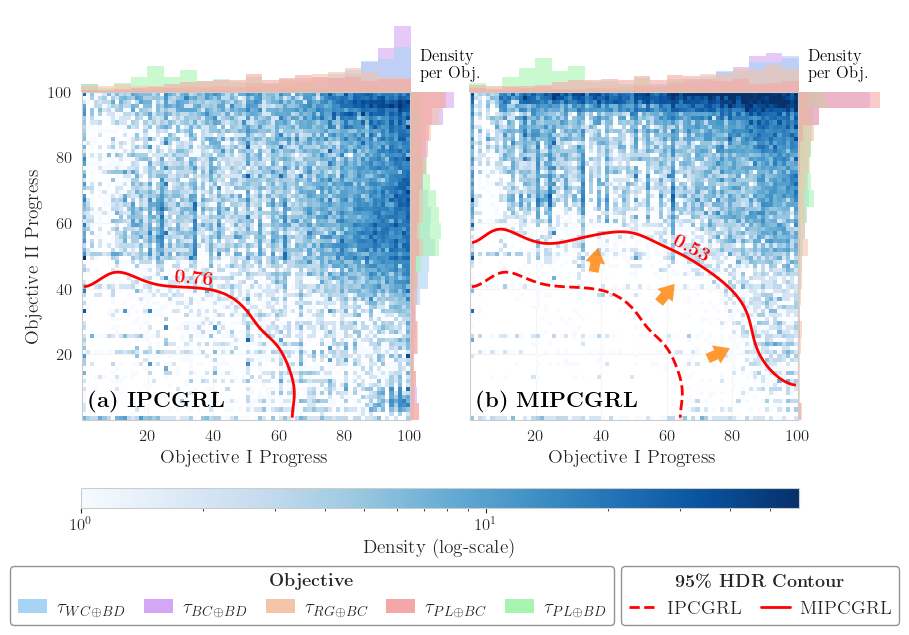

In [7]:
sigma=5.
threshold=(0.0,0.95)
visualization_all_multitask_heatmap(ipcgrl_df, mipcgrl_df,
                                density_sigma=sigma,
                                density_mass_levels=threshold,
)